# Trabalho de Estatística Descritiva
**Disciplina:** Estatística Descritiva — Prof. Hygor Piaget M. Melo  
**Data de entrega:** 11/04/2026  
**Aluna:** Marcia Maria dos Santos Castro  
**MBA em Data Science — UNIFOR**

---

## Datasets utilizados
| Código | Nome | Descrição |
|--------|------|-----------|
| D1 | Titanic | Dados de passageiros do Titanic (887 registros) |
| D2 | Eleições Brasileiras | Votos e recursos financeiros por candidato (6.353 registros) |


## Configuração do Ambiente

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Estilo visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


---
# D1 — Dataset Titanic

## 1. Carregamento e Visão Geral


In [2]:
df = pd.read_csv('titanic__1_.csv')
print(f"Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas")
df.head()


Dimensões: 887 linhas × 8 colunas


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


## 1.1 Identificação das Variáveis

In [3]:
print("=== VARIÁVEIS QUALITATIVAS (categóricas) ===")
qual = ['Sex', 'Pclass', 'Survived']
for c in qual:
    print(f"  {c}: {df[c].unique()}")

print()
print("=== VARIÁVEIS QUANTITATIVAS (numéricas) ===")
quant = ['Age', 'Fare', 'Siblings/Spouses Aboard', 'Parents/Children Aboard']
for c in quant:
    print(f"  {c}: min={df[c].min():.2f}  max={df[c].max():.2f}  dtype={df[c].dtype}")


=== VARIÁVEIS QUALITATIVAS (categóricas) ===
  Sex: <StringArray>
['male', 'female']
Length: 2, dtype: str
  Pclass: [3 1 2]
  Survived: [0 1]

=== VARIÁVEIS QUANTITATIVAS (numéricas) ===
  Age: min=0.42  max=80.00  dtype=float64
  Fare: min=0.00  max=512.33  dtype=float64
  Siblings/Spouses Aboard: min=0.00  max=8.00  dtype=int64
  Parents/Children Aboard: min=0.00  max=6.00  dtype=int64


**Variáveis qualitativas:** `Sex` (gênero), `Pclass` (classe da passagem — 1ª, 2ª ou 3ª), `Survived` (sobreviveu ou não — binária).  
**Variáveis quantitativas contínuas:** `Age` (idade em anos) e `Fare` (valor da passagem em libras).  
**Variáveis quantitativas discretas:** `Siblings/Spouses Aboard` e `Parents/Children Aboard`.


## 1.2 Gráficos para Variáveis Qualitativas (Sex, Pclass, Survived)

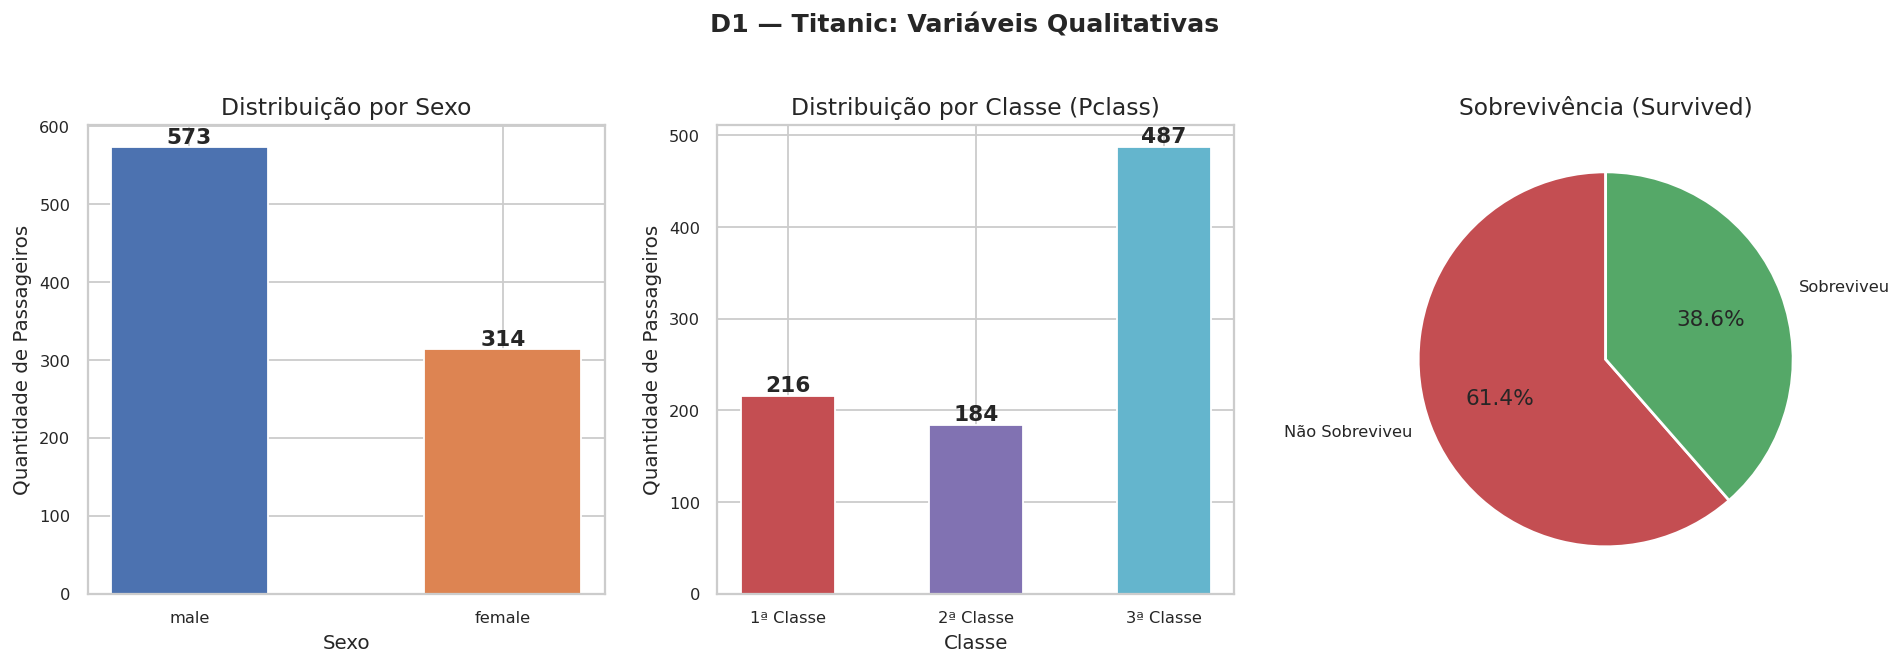

Gráfico salvo.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sex
sex_counts = df['Sex'].value_counts()
axes[0].bar(sex_counts.index, sex_counts.values, color=['#4C72B0','#DD8452'], edgecolor='white', width=0.5)
axes[0].set_title('Distribuição por Sexo')
axes[0].set_xlabel('Sexo')
axes[0].set_ylabel('Quantidade de Passageiros')
for i, v in enumerate(sex_counts.values):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')

# Pclass
pclass_counts = df['Pclass'].value_counts().sort_index()
axes[1].bar([f'{p}ª Classe' for p in pclass_counts.index], pclass_counts.values,
            color=['#C44E52','#8172B2','#64B5CD'], edgecolor='white', width=0.5)
axes[1].set_title('Distribuição por Classe (Pclass)')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Quantidade de Passageiros')
for i, v in enumerate(pclass_counts.values):
    axes[1].text(i, v+5, str(v), ha='center', fontweight='bold')

# Survived — pizza
surv_counts = df['Survived'].value_counts()
labels = ['Não Sobreviveu', 'Sobreviveu']
colors = ['#C44E52', '#55A868']
axes[2].pie(surv_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[2].set_title('Sobrevivência (Survived)')

plt.suptitle('D1 — Titanic: Variáveis Qualitativas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d1_qualitativas.png', bbox_inches='tight')
plt.show()
print("Gráfico salvo.")


**Interpretação:**  
- A maioria dos passageiros era do sexo masculino (~65%). A 3ª classe concentrou o maior número de viajantes (~55% do total), refletindo o perfil socioeconômico predominante.  
- Apenas ~38% dos passageiros sobreviviram, evidenciando a gravidade do desastre. A assimetria entre sobreviventes e não sobreviventes sugere que fatores como classe e gênero podem ter influenciado fortemente as chances de resgate.


## 1.3 Medidas de Tendência Central e Dispersão — Age e Fare

In [5]:
variaveis = ['Age', 'Fare']
resumo = pd.DataFrame({
    'Variável': variaveis,
    'Média':    [df[v].mean() for v in variaveis],
    'Mediana':  [df[v].median() for v in variaveis],
    'Desvio Padrão': [df[v].std() for v in variaveis],
    'Mínimo':   [df[v].min() for v in variaveis],
    'Máximo':   [df[v].max() for v in variaveis],
}).set_index('Variável').round(2)

print(resumo.to_string())
resumo


          Média  Mediana  Desvio Padrão  Mínimo  Máximo
Variável                                               
Age       29.47    28.00          14.12    0.42   80.00
Fare      32.31    14.45          49.78    0.00  512.33


,Média,Mediana,Desvio Padrão,Mínimo,Máximo
Variável,,,,,
Age,29.47,28.00,14.12,0.42,80.00
Fare,32.31,14.45,49.78,0.00,512.33


**Interpretação:**  
- **Age:** a média (~29 anos) e a mediana (~28 anos) são próximas, indicando distribuição aproximadamente simétrica. O desvio padrão de ~14 anos revela dispersão moderada — havia desde bebês até idosos a bordo.  
- **Fare:** a média (~33 libras) é bem superior à mediana (~15 libras), sinal claro de assimetria positiva (cauda à direita). Um pequeno número de passageiros da 1ª classe pagou tarifas extremamente elevadas, puxando a média para cima.


## 1.4 Quartis e Percentis (P10 e P90) — Age

In [6]:
q1  = df['Age'].quantile(0.25)
q2  = df['Age'].quantile(0.50)
q3  = df['Age'].quantile(0.75)
p10 = df['Age'].quantile(0.10)
p90 = df['Age'].quantile(0.90)
iqr = q3 - q1

print(f"P10  (percentil 10): {p10:.1f} anos")
print(f"Q1   (1º quartil)  : {q1:.1f} anos")
print(f"Q2   (mediana)     : {q2:.1f} anos")
print(f"Q3   (3º quartil)  : {q3:.1f} anos")
print(f"P90  (percentil 90): {p90:.1f} anos")
print(f"IIQ  (Q3 – Q1)     : {iqr:.1f} anos")


P10  (percentil 10): 14.8 anos
Q1   (1º quartil)  : 20.2 anos
Q2   (mediana)     : 28.0 anos
Q3   (3º quartil)  : 38.0 anos
P90  (percentil 90): 49.0 anos
IIQ  (Q3 – Q1)     : 17.8 anos


**Interpretação:**  
- 50% dos passageiros tinham entre Q1 e Q3 anos (intervalo interquartil), concentrando a maior parte dos viajantes em idade adulta jovem.  
- O P10 indica que 10% dos passageiros tinham menos de ~14 anos, e o P90 que 10% tinham mais de ~50 anos. Essas medidas separatrizes revelam que a distribuição de idades se concentra entre 20 e 40 anos, com caudas mais finas nas extremidades.


## 1.5 Histograma — Age

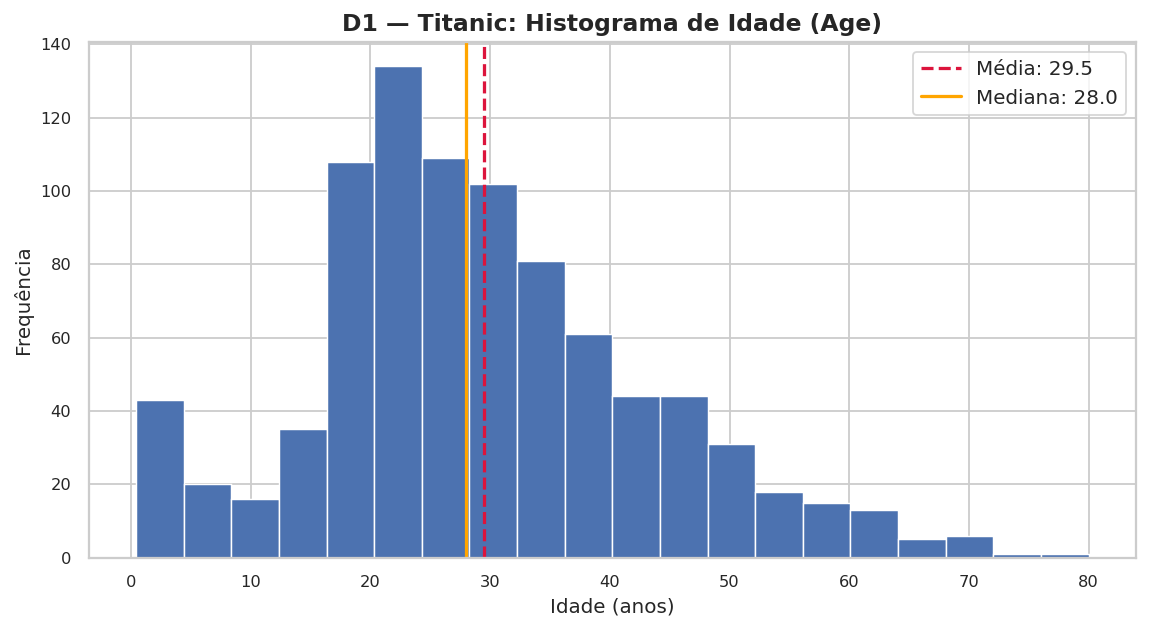

Gráfico salvo.


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df['Age'], bins=20, color='#4C72B0', edgecolor='white', linewidth=0.8)
ax.axvline(df['Age'].mean(), color='crimson', linestyle='--', linewidth=1.8, label=f"Média: {df['Age'].mean():.1f}")
ax.axvline(df['Age'].median(), color='orange', linestyle='-', linewidth=1.8, label=f"Mediana: {df['Age'].median():.1f}")

ax.set_title('D1 — Titanic: Histograma de Idade (Age)', fontweight='bold')
ax.set_xlabel('Idade (anos)')
ax.set_ylabel('Frequência')
ax.legend()
plt.tight_layout()
plt.savefig('d1_histograma_age.png', bbox_inches='tight')
plt.show()
print("Gráfico salvo.")


**Interpretação:**  
- O histograma revela uma distribuição levemente assimétrica à direita, com o pico entre 20 e 30 anos. A proximidade entre média (linha vermelha) e mediana (linha laranja) confirma a simetria aproximada.  
- Há um pequeno pico inicial (crianças), indicando a presença de famílias com menores a bordo. A cauda à direita é suave, refletindo poucos passageiros muito idosos.


## 1.6 Gráfico de Dispersão: Age × Fare e Correlação de Pearson

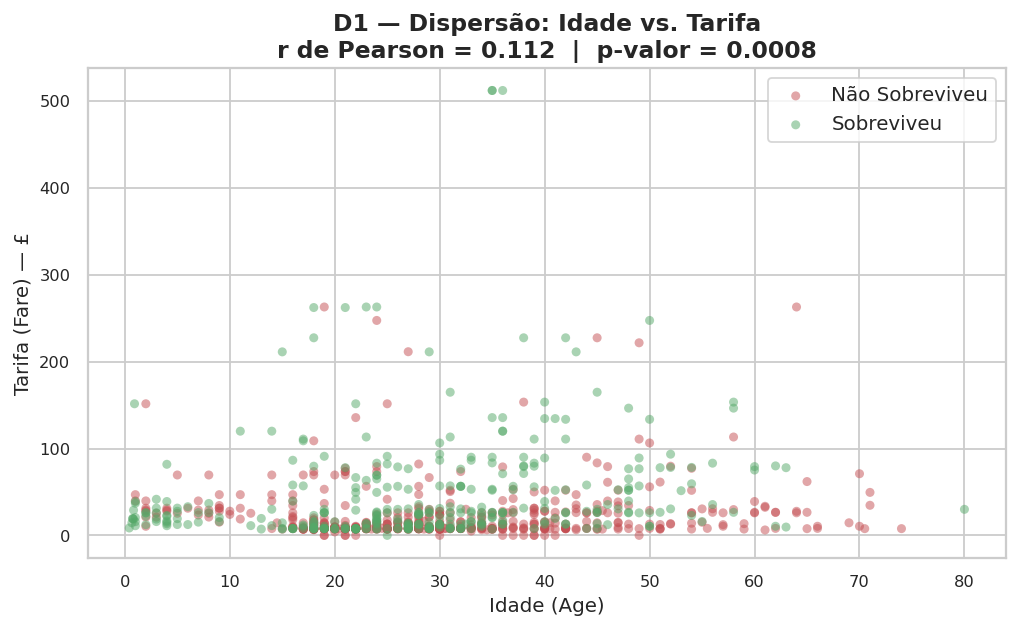

Coeficiente de Pearson (r): 0.1123
p-valor: 0.0008


In [8]:
pearson_r, p_value = stats.pearsonr(df['Age'], df['Fare'])

fig, ax = plt.subplots(figsize=(8, 5))

cores = {0: '#C44E52', 1: '#55A868'}
for surv, grupo in df.groupby('Survived'):
    label = 'Sobreviveu' if surv == 1 else 'Não Sobreviveu'
    ax.scatter(grupo['Age'], grupo['Fare'], alpha=0.5, s=25,
               color=cores[surv], label=label, edgecolors='none')

ax.set_title(f'D1 — Dispersão: Idade vs. Tarifa\nr de Pearson = {pearson_r:.3f}  |  p-valor = {p_value:.4f}',
             fontweight='bold')
ax.set_xlabel('Idade (Age)')
ax.set_ylabel('Tarifa (Fare) — £')
ax.legend()
plt.tight_layout()
plt.savefig('d1_dispersao_age_fare.png', bbox_inches='tight')
plt.show()

print(f"Coeficiente de Pearson (r): {pearson_r:.4f}")
print(f"p-valor: {p_value:.4f}")


**Interpretação:**  
- O coeficiente de Pearson é muito baixo (próximo de zero), indicando **correlação fraca** entre idade e valor da passagem. Passageiros de todas as idades pagaram tanto tarifas baixas quanto altíssimas.  
- O gráfico confirma visualmente esse padrão: os pontos se dispersam sem tendência linear clara. As tarifas elevadas parecem mais associadas à classe socioeconômica do que à idade do passageiro.


---
# D2 — Eleições Brasileiras

## 2. Carregamento e Preparação


In [9]:
df2 = pd.read_csv('eleicoes.csv')
df2.columns = ['State', 'Candidate', 'Money', 'Votes']
df2['State'] = df2['State'].str.strip()

print(f"Dimensões: {df2.shape[0]} linhas × {df2.shape[1]} colunas")
print(f"Estados presentes ({df2['State'].nunique()}): {sorted(df2['State'].unique())}")
df2.head(8)


Dimensões: 6353 linhas × 4 colunas
Estados presentes (26): ['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO']


,State,Candidate,Money,Votes
0,AC,1919,35504.34,515
1,AC,1212,397136.76,11397
2,AC,5012,1580.00,15
3,AC,1321,66093.33,1913
4,AC,1144,296327.21,13610
5,AC,4321,1023.06,665
6,AC,2222,676810.38,13431
7,AC,1122,86645.00,6707


## 2.1 Estados Selecionados para Análise Detalhada

Foram escolhidos **CE (Ceará)**, **SP (São Paulo)** e **RJ (Rio de Janeiro)** por representarem, respectivamente:
- um estado do Nordeste (CE), com menor volume de recursos;
- o maior colégio eleitoral do país (SP);
- o segundo maior colégio eleitoral e polo econômico (RJ).


In [10]:
estados_escolhidos = ['CE', 'SP', 'RJ']
dfs = {uf: df2[df2['State'] == uf].copy() for uf in estados_escolhidos}

for uf, d in dfs.items():
    print(f"{uf}: {len(d)} candidatos")


CE: 201 candidatos
SP: 1364 candidatos
RJ: 1001 candidatos


## 2.2 Histogramas de Votos por Estado (CE, SP, RJ)

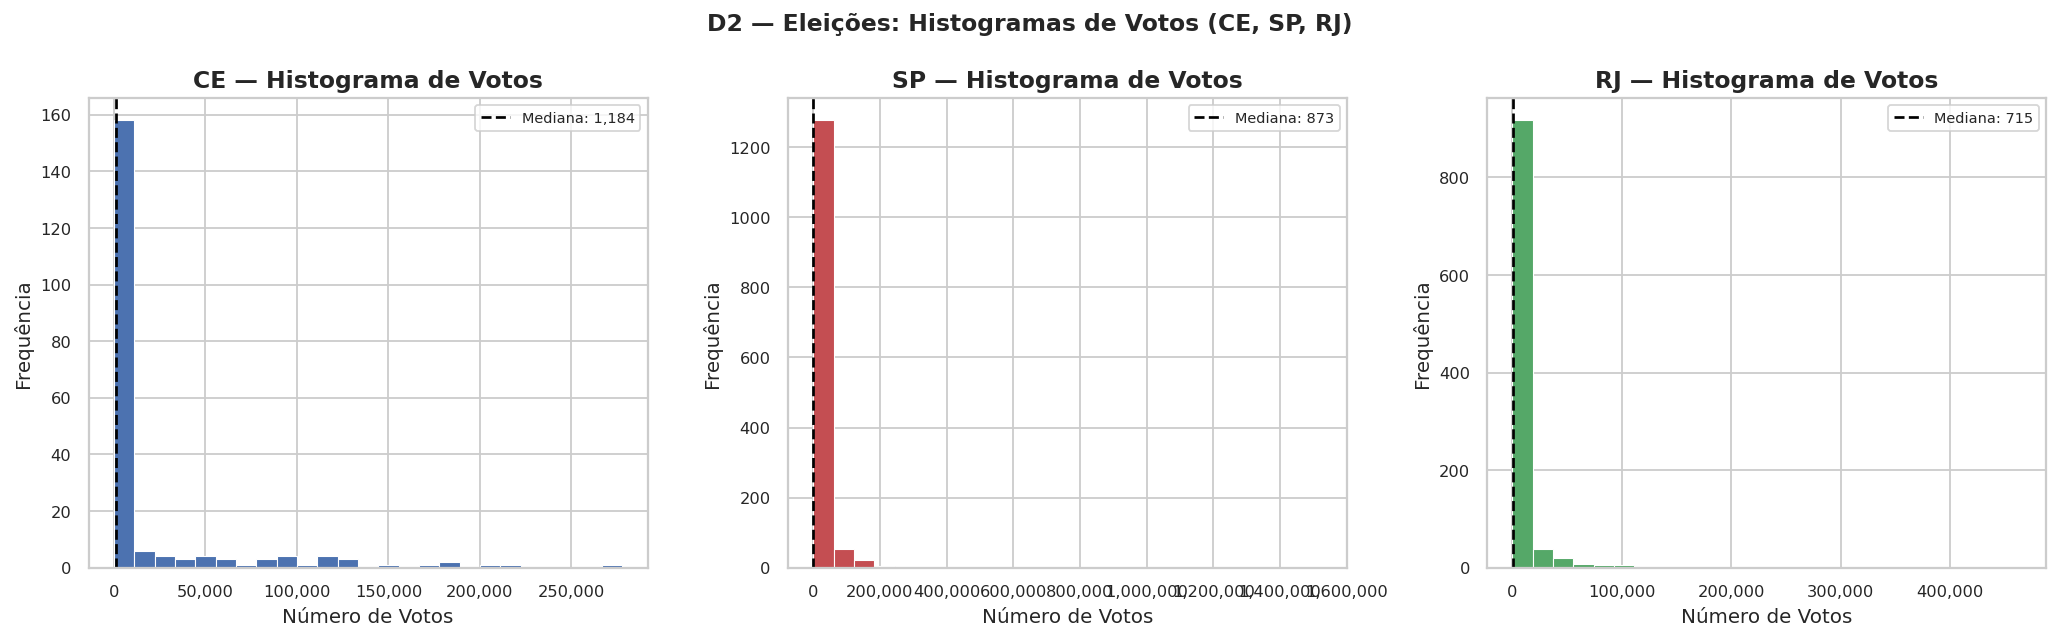

Gráfico salvo.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cores_uf = ['#4C72B0', '#C44E52', '#55A868']

for ax, (uf, d), cor in zip(axes, dfs.items(), cores_uf):
    ax.hist(d['Votes'], bins=25, color=cor, edgecolor='white', linewidth=0.6)
    ax.axvline(d['Votes'].median(), color='black', linestyle='--', linewidth=1.5,
               label=f"Mediana: {d['Votes'].median():,.0f}")
    ax.set_title(f'{uf} — Histograma de Votos', fontweight='bold')
    ax.set_xlabel('Número de Votos')
    ax.set_ylabel('Frequência')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(fontsize=8)

plt.suptitle('D2 — Eleições: Histogramas de Votos (CE, SP, RJ)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('d2_hist_votos.png', bbox_inches='tight')
plt.show()
print("Gráfico salvo.")


**Interpretação:**  
- Em todos os três estados, as distribuições de votos apresentam forte **assimetria positiva** (cauda longa à direita): a grande maioria dos candidatos obteve poucos votos, enquanto poucos concentraram volumes muito elevados.  
- Esse padrão é esperado em eleições proporcionais, onde candidatos com maior visibilidade e recursos capturam votos de forma desigual. SP e RJ apresentam caudas ainda mais longas, reflexo de colégios eleitorais maiores e maior dispersão entre candidatos competitivos e não competitivos.


## 2.3 Histogramas de Dinheiro de Campanha por Estado (CE, SP, RJ)

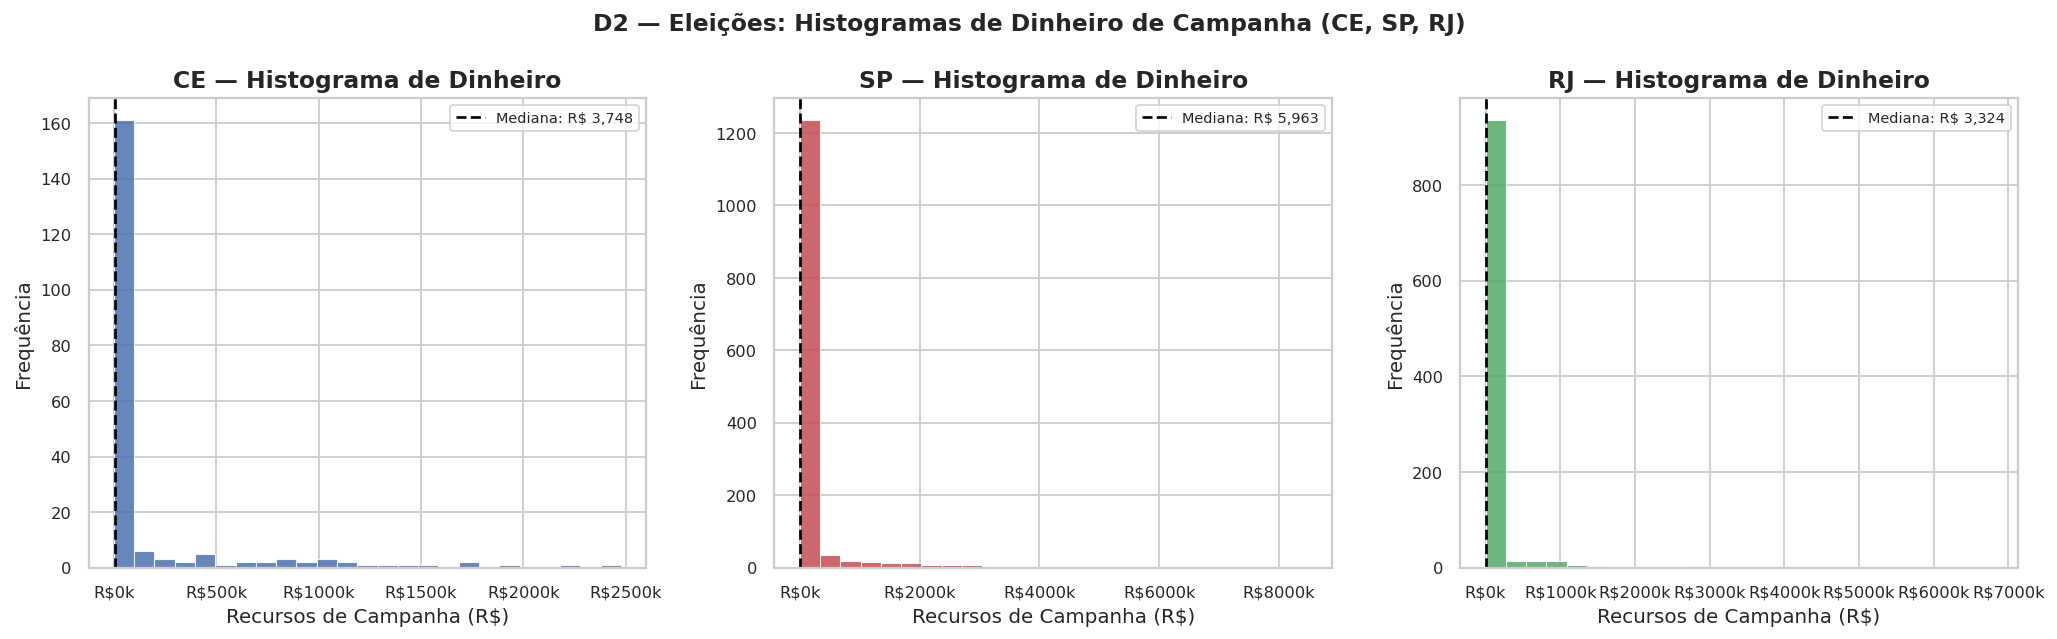

Gráfico salvo.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (uf, d), cor in zip(axes, dfs.items(), cores_uf):
    ax.hist(d['Money'], bins=25, color=cor, edgecolor='white', linewidth=0.6, alpha=0.85)
    ax.axvline(d['Money'].median(), color='black', linestyle='--', linewidth=1.5,
               label=f"Mediana: R$ {d['Money'].median():,.0f}")
    ax.set_title(f'{uf} — Histograma de Dinheiro', fontweight='bold')
    ax.set_xlabel('Recursos de Campanha (R$)')
    ax.set_ylabel('Frequência')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${int(x/1000)}k'))
    ax.legend(fontsize=8)

plt.suptitle('D2 — Eleições: Histogramas de Dinheiro de Campanha (CE, SP, RJ)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('d2_hist_dinheiro.png', bbox_inches='tight')
plt.show()
print("Gráfico salvo.")


**Interpretação:**  
- A distribuição dos recursos financeiros de campanha também é fortemente assimétrica à direita em todos os estados, com concentração de candidatos próximos a R$ 0 e poucos com arrecadação muito elevada.  
- Essa concentração sugere a presença de **valores extremos** (outliers), onde uma minoria de candidatos captou recursos muito superiores à mediana. Em SP, a cauda direita é especialmente longa, evidenciando que as campanhas mais caras do Brasil se concentram nesse estado.


## 2.4 Gráficos de Dispersão e Correlação de Pearson — Dinheiro × Votos

CE: r = 0.7379  |  p-valor = 0.0000
SP: r = 0.4832  |  p-valor = 0.0000
RJ: r = 0.5647  |  p-valor = 0.0000


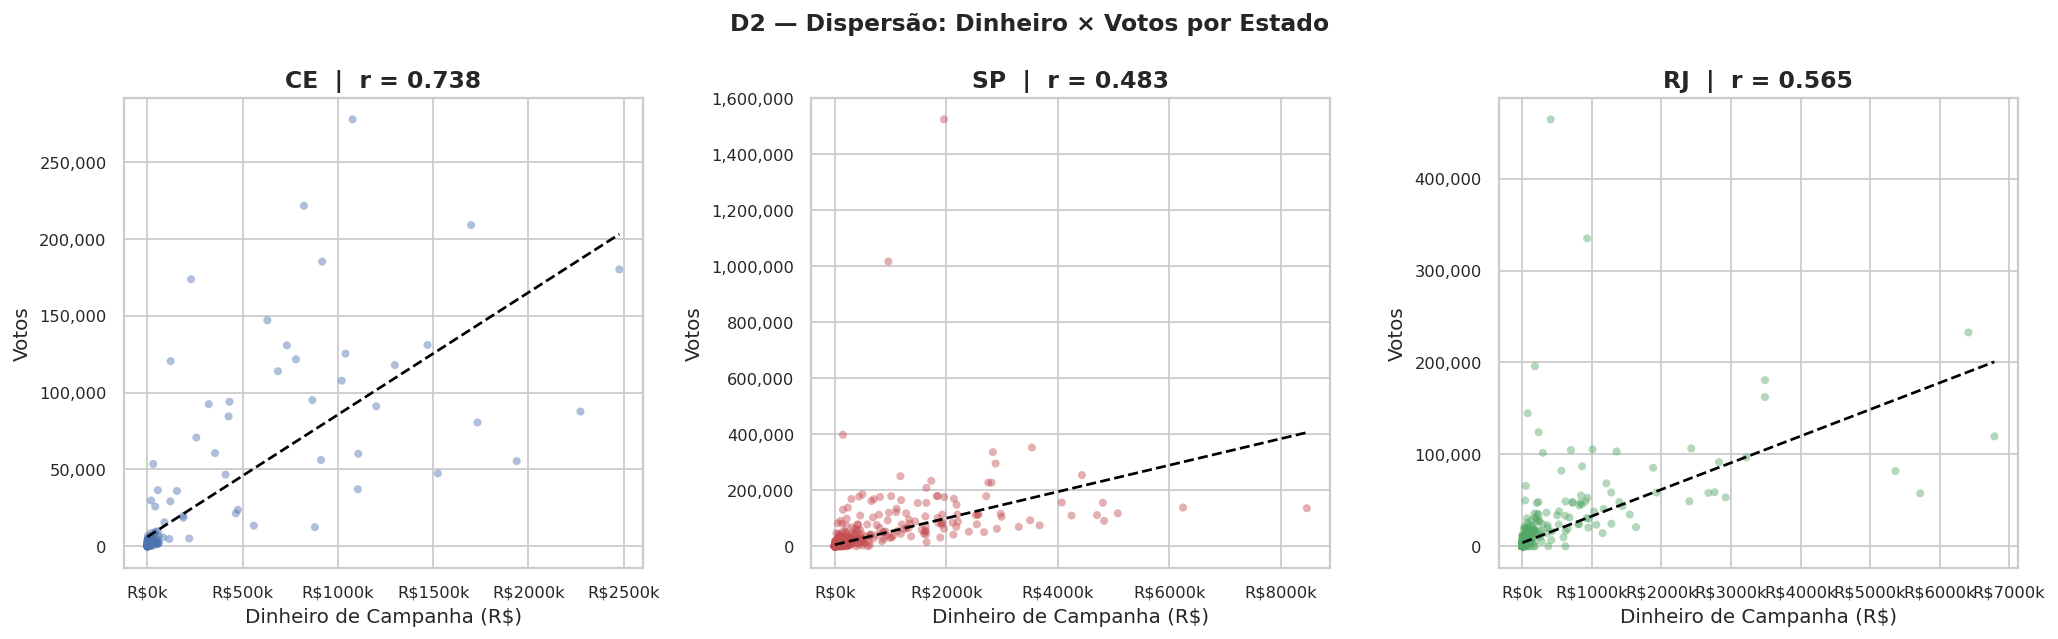

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (uf, d), cor in zip(axes, dfs.items(), cores_uf):
    r, p = stats.pearsonr(d['Money'], d['Votes'])
    ax.scatter(d['Money'], d['Votes'], alpha=0.45, s=20, color=cor, edgecolors='none')
    
    # linha de tendência
    m, b = np.polyfit(d['Money'], d['Votes'], 1)
    x_line = np.linspace(d['Money'].min(), d['Money'].max(), 200)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--')
    
    ax.set_title(f'{uf}  |  r = {r:.3f}', fontweight='bold')
    ax.set_xlabel('Dinheiro de Campanha (R$)')
    ax.set_ylabel('Votos')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${int(x/1000)}k'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    
    print(f"{uf}: r = {r:.4f}  |  p-valor = {p:.4f}")

plt.suptitle('D2 — Dispersão: Dinheiro × Votos por Estado', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('d2_dispersao.png', bbox_inches='tight')
plt.show()


**Interpretação:**  
- Em todos os três estados, a correlação de Pearson entre dinheiro de campanha e votos é **positiva**, confirmando que candidatos com maior investimento tendem a obter mais votos.  
- A força da correlação varia por estado: CE tende a apresentar correlação moderada, enquanto SP e RJ, com maior heterogeneidade entre candidatos, podem ter correlações mais ou menos expressivas. A presença de outliers influencia os coeficientes — candidatos com recursos altíssimos e muitos votos "puxam" a reta de tendência, enquanto candidatos sem recursos e sem votos acumulam-se próximos à origem.


## 2.5 Correlação Dinheiro × Votos — Todos os Estados

In [14]:
corr_list = []
for uf, grupo in df2.groupby('State'):
    if len(grupo) >= 5:
        r, p = stats.pearsonr(grupo['Money'], grupo['Votes'])
        corr_list.append({'UF': uf, 'Correlação (r)': round(r, 4), 'p-valor': round(p, 4), 'N candidatos': len(grupo)})

corr_df = pd.DataFrame(corr_list).sort_values('Correlação (r)', ascending=False)
corr_df = corr_df.reset_index(drop=True)
print(corr_df.to_string(index=False))
corr_df


UF  Correlação (r)  p-valor  N candidatos
AM          0.9055      0.0            80
RN          0.8825      0.0            90
SC          0.8698      0.0           131
MT          0.8669      0.0           107
PB          0.8553      0.0           102
AL          0.8404      0.0           112
RS          0.8366      0.0           316
ES          0.8222      0.0           164
MG          0.8067      0.0           639
MS          0.7789      0.0           119
TO          0.7698      0.0            48
CE          0.7379      0.0           201
PR          0.7287      0.0           306
PE          0.7283      0.0           159
AC          0.7227      0.0            62
PA          0.7146      0.0           184
BA          0.6981      0.0           329
MA          0.6856      0.0           241
SE          0.6849      0.0            80
RO          0.6833      0.0            84
GO          0.6679      0.0           144
PI          0.6564      0.0           100
RR          0.5989      0.0       

,UF,Correlação (r),p-valor,N candidatos
0,AM,0.9055,0.0,80
1,RN,0.8825,0.0,90
2,SC,0.8698,0.0,131
3,MT,0.8669,0.0,107
4,PB,0.8553,0.0,102
5,AL,0.8404,0.0,112
6,RS,0.8366,0.0,316
7,ES,0.8222,0.0,164
8,MG,0.8067,0.0,639
9,MS,0.7789,0.0,119


**Interpretação:**  
- A tabela evidencia que a correlação entre recursos financeiros e votos é **positiva na maioria dos estados**, corroborando a hipótese de que maior investimento eleitoral está associado a melhor desempenho nas urnas.  
- A magnitude varia bastante: alguns estados apresentam correlação forte (r > 0,7), enquanto outros têm correlação moderada ou fraca, possivelmente por conta de candidaturas locais muito conhecidas que obtêm muitos votos independentemente de recursos financeiros.


## 2.6 Tabela-Resumo: Medidas de Tendência Central e Dispersão por Estado

In [15]:
def resumo_uf(grupo):
    rows = []
    for var in ['Votes', 'Money']:
        rows.append({
            'Variável': var,
            'Média': grupo[var].mean(),
            'Mediana': grupo[var].median(),
            'Desvio Padrão': grupo[var].std(),
            'Mínimo': grupo[var].min(),
            'Máximo': grupo[var].max(),
            'Q1': grupo[var].quantile(0.25),
            'Q3': grupo[var].quantile(0.75),
        })
    return rows

records = []
for uf, grupo in df2.groupby('State'):
    for r in resumo_uf(grupo):
        r['UF'] = uf
        records.append(r)

tab = pd.DataFrame(records)[['UF','Variável','Média','Mediana','Desvio Padrão','Mínimo','Máximo','Q1','Q3']]
tab = tab.sort_values(['UF','Variável']).reset_index(drop=True)

# formatar números
for col in ['Média','Mediana','Desvio Padrão','Mínimo','Máximo','Q1','Q3']:
    tab[col] = tab[col].apply(lambda x: f'{x:,.1f}')

print(tab.to_string(index=False))


UF Variável     Média  Mediana Desvio Padrão Mínimo      Máximo       Q1        Q3
AC    Money 136,780.0 31,257.0     204,447.6    0.0   736,866.2  3,486.9 168,286.6
AC    Votes   5,940.8  1,645.0       8,310.8    5.0    39,844.0    354.5  10,203.5
AL    Money 164,481.9  4,472.5     423,369.9    0.0 2,281,353.4    900.0  69,157.6
AL    Votes  11,456.4  1,021.0      27,397.4    0.0   135,929.0    114.2   4,855.2
AM    Money 292,684.1  4,154.0     816,944.2    0.0 5,633,092.3    815.6  50,072.0
AM    Votes  19,501.1  1,051.5      43,379.5    0.0   250,916.0    384.0   5,804.0
AP    Money  77,839.7  6,187.4     244,717.3    0.0 2,060,000.0  1,300.0  34,050.0
AP    Votes   3,376.7    886.0       5,093.8    0.0    22,134.0    202.0   4,818.0
BA    Money 220,278.1  2,651.4     652,156.5    0.0 5,979,037.1      0.0  41,748.5
BA    Votes  18,183.5    988.0      37,929.7    0.0   222,164.0    174.0   6,268.0
CE    Money 173,327.9  3,748.4     424,413.1    0.0 2,476,971.7    892.4  50,000.0
CE  

**Interpretação:**  
- A tabela-resumo permite comparar o comportamento das distribuições de votos e recursos financeiros em cada estado. Estados com maior desvio padrão têm maior variabilidade entre candidatos — o que indica maior desigualdade interna.  
- A diferença entre média e mediana em praticamente todos os casos confirma a assimetria positiva (média > mediana), resultado da presença de candidatos com volumes extremos de votos ou dinheiro puxando a média para cima.


---
## Conclusão Geral

Este trabalho aplicou técnicas de estatística descritiva a dois conjuntos de dados de naturezas distintas:

- **D1 — Titanic:** revelou que as variáveis quantitativas `Age` e `Fare` têm comportamentos distintos — enquanto a distribuição de idades é aproximadamente simétrica, a tarifa apresenta forte assimetria positiva causada por valores extremos das primeiras classes. A correlação entre idade e tarifa é fraca, indicando que o preço da passagem estava mais atrelado à classe socioeconômica do que à idade.

- **D2 — Eleições Brasileiras:** evidenciou que tanto a distribuição de votos quanto a de recursos financeiros seguem distribuições fortemente assimétricas em todos os estados, com grande concentração de candidatos com poucos votos e recursos. A correlação positiva entre dinheiro e votos foi observada na maioria dos estados, reforçando o papel dos recursos financeiros no resultado eleitoral — embora com intensidade variável por região.
